In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RAW_DATA_PATH, TARGET_COL
from src.preprocessing import load_raw_data, clean_data

sns.set_style('whitegrid')

## Load and inspect

In [2]:
df_raw = load_raw_data(RAW_DATA_PATH)
print(df_raw.shape)
df_raw.dtypes

(7043, 21)


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [3]:
df_raw.isnull().sum()  # check nulls before cleaning

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Clean (TotalCharges -> numeric, drop nulls, encode target, engineer avg_monthly_spend)

In [4]:
df = clean_data(df_raw)
print(df.shape)
df[TARGET_COL].value_counts(normalize=True)

(7032, 21)


Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

## Baseline sanity check: always-predict-majority accuracy

In [5]:
baseline_acc = df[TARGET_COL].value_counts(normalize=True).max()
print(f'Naive baseline accuracy (always predict majority class): {baseline_acc:.3f}')

Naive baseline accuracy (always predict majority class): 0.734


## Churn distribution

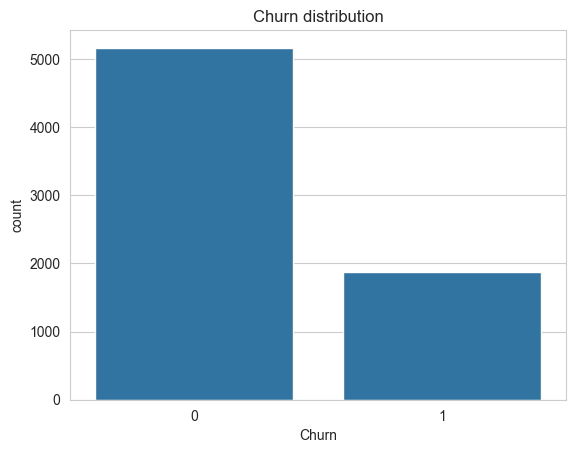

In [6]:
ax = sns.countplot(data=df, x=TARGET_COL)
ax.set_title('Churn distribution')
plt.show()

## Churn rate by Contract type — the headline insight

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn, dtype: float64


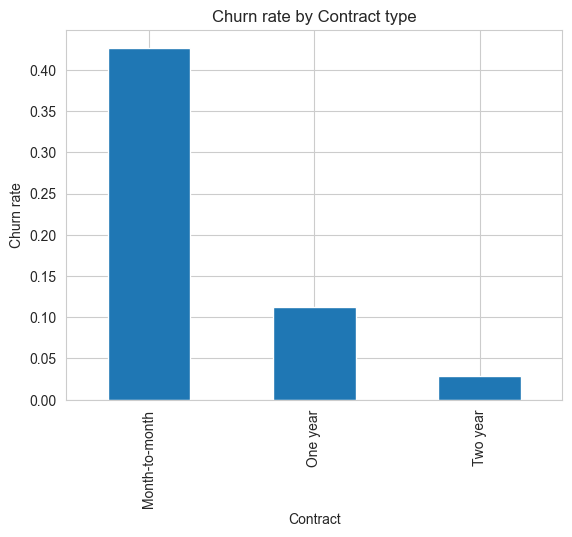

In [7]:
contract_churn = df.groupby('Contract')[TARGET_COL].mean().sort_values(ascending=False)
print(contract_churn)
contract_churn.plot(kind='bar', title='Churn rate by Contract type')
plt.ylabel('Churn rate')
plt.show()

## Distributions: tenure, MonthlyCharges, TotalCharges

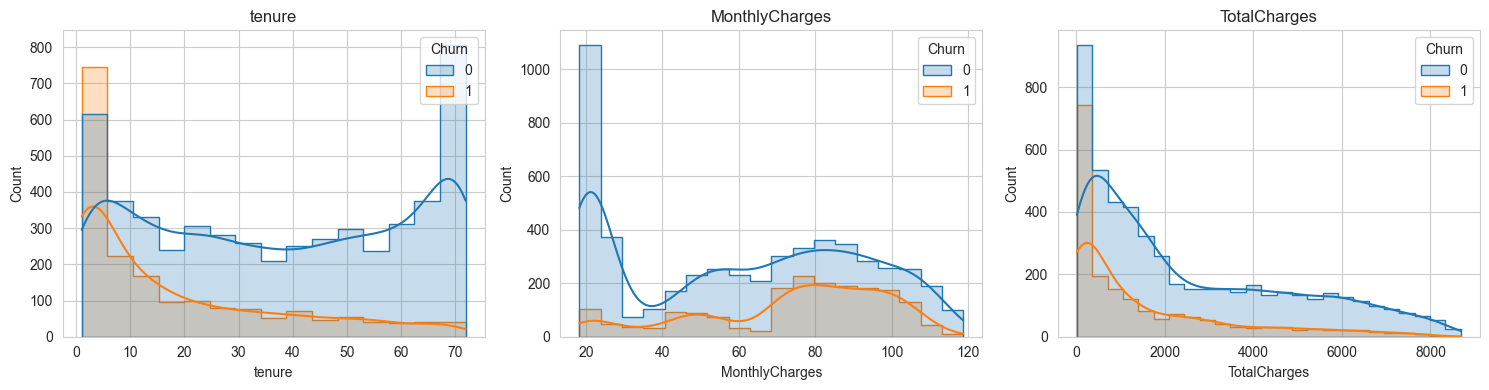

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue=TARGET_COL, kde=True, ax=ax, element='step')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [9]:
# Save cleaned data for the modeling notebook
df.to_csv('../data/telco_churn_clean.csv', index=False)